In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

In [2]:
# df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final.parquet")
# df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final_20250620.parquet")
df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final_20250627.parquet")
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Final Drop Columns

In [3]:
all_feats = [
    'time_diff',
    'CntUnique_CardNo_by_currencyCode_L30D',
    'CntUnique_CardNo_by_cardAcceptor_country_L30D',
    'CntUnique_CardNo_by_cardAcceptor_country_L7D',
    'CntUnique_CardNo_by_currencyCode_L14D',
    'POSMode_FE',
    'CntUnique_CardNo_by_cardAcceptor_country_L14D',
    'CntUnique_CardNo_by_currencyCode_L90D',
    'MCC Category_FE',
    'CntUnique_MCC_by_CardNo_L1H',
    'CntUnique_CardNo_by_cardAcceptor_country_L90D',
    'CntUnique_CardNo_by_currencyCode_L1D',
    'CntUnique_CardNo_by_currencyCode_L7D',
    'TransactionType_FE',
    'TxnCount_to_MCC_cat_L90D',
    'TxnCount_to_MCC_L90D',
    'Transaction Amount',
    'TxnCount_to_MCC_details_L90D',
    'TxnCount_to_cardAcceptor_cat_L90D',
    'CntUnique_MCC_by_CardNo_L15M',
    'Sum_Amt_to_cardAcceptor_country_L90D',
    'Max_Amt_to_MCC_L90D',
    'Max_Amt_to_cardAcceptor_country_L90D',
    'Sum_Amt_to_MCC_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L1H',
    'Cat Card Acceptor Name_FE',
    'Avg_Amt_to_cardAcceptor_country_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L14D',
    'Avg_Amt_to_MCC_L90D',
    'TxnCount_to_countryCode_L90D',
    'TotalTrxAmount30Mi',
    'TxnCount_to_MCC_details_L30D',
    'TxnCount_to_MCC_L30D',
    'TotalTrxAmount15Mi',
    'CntUnique_CardNo_by_cardAcceptor_country_L15M',
    'CntUnique_CardNo_by_cardAcceptor_cat_L30D',
    'TotalTrxAmountL5min',
    'TxnCount_to_MCC_cat_L30D',
    'TotalTrxAmount10Mi',
    'Sum_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L7D',
    'Max_Amt_to_MCC_cat_L90D',
    'TxnCount_to_countryCode_L30D',
    'Sum_Amt_to_MCC_cat_L90D',
    'Sum_Amt_to_cardAcceptor_country_L30D',
    'TxnCount_to_cardAcceptor_cat_L30D',
    'Max_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L1D',
    'Avg_Amt_to_MCC_cat_L90D',
    'TxnCount_L90D',
    'Avg_Amt_to_cardAcceptor_cat_L90D',
    'TxnCount_to_MCC_catcode_L90D',
    'Max_Amt_L15M',
    'Avg_Amt_to_cardAcceptor_country_L30D',
    'PINEntryCapability_FE',
    'Max_Amt_to_cardAcceptor_country_L30D',
    'TxnCount_L30D',
    'TxnCount_to_countryCode_L14D',
    'Sum_Amt_to_countryCode_L90D',
    'Max_Amt_to_MCC_L30D',
    'TxnCount_to_cardAcceptor_country_L14D',
    'TotalTrxAmountL1D',
    'Max_Amt_to_cardAcceptor_country_L14D',
    'Sum_Amt_to_MCC_cat_L30D',
    'Currency_FE',
    'Max_Amt_L1H',
    'Sum_Amt_to_cardAcceptor_country_L15M',
    'Sum_Amt_L90D',
    'TxnCount_to_MCC_catcode_L30D',
    'Max_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_MCC_L30D',
    'Max_Amt_to_cardAcceptor_country_L1H',
    'TxnCount_to_cardAcceptor_cat_L14D',
    'Max_Amt_to_cardAcceptor_country_L15M',
    'TxnCount_to_MCC_cat_L14D',
    'TxnCount_to_MCC_L14D',
    'Max_Amt_to_MCC_cat_L30D',
    'CntUnique_CardNo_by_MCC_L1D',
    'CreditLimit',
    'Avg_Amt_to_MCC_cat_L30D',
    'Sum_Amt_to_countryCode_L30D',
    'Avg_Amt_to_MCC_L30D',
    'TxnCount_L14D',
    'Sum_Amt_L30D',
    'TxnCount_to_MCC_details_L14D',
    'CntUnique_CardNo_by_currencyCode_L1H',
    'Sum_Amt_to_cardAcceptor_country_L1H',
    'Sum_Amt_to_cardAcceptor_country_L14D',
    'Sum_Amt_to_countryCode_L15M',
    'Max_Amt_to_countryCode_L90D',
    'Avg_Amt_to_cardAcceptor_country_L14D',
    'Avg_Amt_to_countryCode_L90D',
    'Sum_Amt_to_cardAcceptor_country_L7D',
    'TxnCount_to_countryCode_L7D',
    'Avg_Amt_to_cardAcceptor_country_L7D',
    'Max_Amt_L90D',
    'Avg_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_cardAcceptor_cat_L30D',
    'Sum_Amt_to_MCC_cat_L1H',
    'Sum_Amt_to_countryCode_L1H',
    'Max_Amt_to_countryCode_L1H',
    'Max_Amt_to_MCC_cat_L15M',
    'Country Code_FE',
    'Max_Amt_to_countryCode_L30D',
    'CardProduct_FE',
    'TotalTrxAmountL7D',
    'Avg_Amt_to_cardAcceptor_country_L15M',
    'Max_Amt_to_cardAcceptor_country_L7D',
    'Sum_Amt_to_countryCode_L14D',
    'Max_Amt_L30D',
    'Max_Amt_to_countryCode_L15M',
    'Avg_Amt_to_countryCode_L30D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L1H',
    'Sum_Amt_to_MCC_cat_L15M',
    'Avg_Amt_L15M',
    'TxnCount_to_MCC_catcode_L14D',
    'Max_Amt_to_MCC_L14D',
    'CntUnique_CardNo_by_MCC_L1H',
    'Max_Amt_to_countryCode_L14D',
    'Max_Amt_to_MCC_cat_L1H',
    'Avg_Amt_L1H',
    'VCardDataInputCapability_FE',
    'TxnCount_L7D',
    'Sum_Amt_to_cardAcceptor_country_L1D',
    'TxnCount_to_cardAcceptor_country_L7D',
    'Sum_Amt_to_MCC_L14D',
    'Max_Amt_L1D',
    'Max_Amt_L14D',
    'Avg_Amt_to_cardAcceptor_cat_L14D',
    'Avg_Amt_to_MCC_cat_L14D',
    'Sum_Amt_L14D',
    'Avg_Amt_to_countryCode_L14D',
    'Max_Amt_to_countryCode_L7D',
    'Avg_Amt_to_countryCode_L1H',
    'Sum_Amt_to_cardAcceptor_cat_L15M',
    'Max_Amt_to_MCC_cat_L14D',
    'TxnCount_to_MCC_L7D',
    'Max_Amt_to_cardAcceptor_cat_L14D',
    'Max_Amt_to_cardAcceptor_country_L1D',
    'Max_Amt_L7D',
    'Avg_Amt_to_cardAcceptor_country_L1H',
    'Avg_Amt_L30D',
    'Max_Amt_to_MCC_cat_L7D',
    'Avg_Amt_to_countryCode_L7D',
    'Max_Amt_to_cardAcceptor_cat_L15M',
    'Avg_Amt_to_MCC_L14D',
    'SourceChannel_FE',
    'Sum_Amt_to_MCC_cat_L14D',
    'Sum_Amt_to_countryCode_L7D',
    'TxnCount_to_cardAcceptor_cat_L7D',
    'Avg_Amt_to_cardAcceptor_cat_L7D',
    'Sum_Amt_to_countryCode_L1D',
    'Avg_Amt_L14D',
    'Max_Amt_to_cardAcceptor_cat_L7D',
    'Avg_Amt_to_countryCode_L15M',
    'Max_Amt_to_countryCode_L1D',
    'Max_Amt_to_MCC_L7D',
    'Avg_Amt_L7D',
    'Avg_Amt_L1D',
    'Sum_Amt_to_cardAcceptor_cat_L14D',
    'Sum_Amt_to_MCC_cat_L7D',
    'Sum_Amt_to_MCC_L7D',
    'Sum_Amt_to_cardAcceptor_cat_L1D',
    'Avg_Amt_to_countryCode_L1D',
    'Max_Amt_to_cardAcceptor_cat_L1D',
    'Sum_Amt_to_cardAcceptor_cat_L7D',
    'Max_Amt_to_MCC_L1H',
    'Avg_Amt_to_cardAcceptor_country_L1D',
    'Max_Amt_to_MCC_cat_L1D',
    'Avg_Amt_to_MCC_cat_L7D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L15M',
    'CustomerSex_FE',
    'Avg_Amt_to_MCC_L7D',
    'Avg_Amt_to_MCC_cat_L1H',
    'Avg_Amt_to_MCC_cat_L15M',
    'Sum_Amt_to_MCC_cat_L1D',
    'Avg_Amt_to_cardAcceptor_cat_L1D',
    'Currency Code_FE',
    'Max_Amt_to_MCC_L15M',
    'Max_Amt_to_MCC_L1D',
    'Sum_Amt_to_MCC_L15M',
    'CardStatus_FE',
    'Sum_Amt_to_MCC_L1H',
    'Sum_Amt_to_cardAcceptor_cat_L1H',
    'Avg_Amt_to_MCC_cat_L1D',
    'Avg_Amt_to_MCC_L1H',
    'Max_Amt_to_cardAcceptor_cat_L1H',
    'AccountStatus_FE',
    'Sum_Amt_to_MCC_L1D',
    'Avg_Amt_to_MCC_L1D',
    'Avg_Amt_to_cardAcceptor_cat_L15M',
    'Avg_Amt_to_cardAcceptor_cat_L1H',
    'Avg_Amt_to_MCC_L15M',
    'CustomerNationality_FE',
    'AvgTrnxHourL15min',
    'AvgTrnxHourL1h',
    'AvgTrnxHourL1d',
    'AvgTrnxHourL14d',
    'AvgTrnxHourL30d'
]

In [3]:
derived_cols = [
    'Avg_Amt_L14D',
    'Avg_Amt_L15M',
    'Avg_Amt_L1D',
    'Avg_Amt_L1H',
    'Avg_Amt_L30D',
    'Avg_Amt_L7D',
    'Avg_Amt_to_MCC_L14D',
    'Avg_Amt_to_MCC_L15M',
    'Avg_Amt_to_MCC_L1D',
    'Avg_Amt_to_MCC_L1H',
    'Avg_Amt_to_MCC_L30D',
    'Avg_Amt_to_MCC_L7D',
    'Avg_Amt_to_MCC_L90D',
    'Avg_Amt_to_countryCode_L14D',
    'Avg_Amt_to_countryCode_L15M',
    'Avg_Amt_to_countryCode_L1D',
    'Avg_Amt_to_countryCode_L1H',
    'Avg_Amt_to_countryCode_L30D',
    'Avg_Amt_to_countryCode_L7D',
    'Avg_Amt_to_countryCode_L90D',
    'CntUnique_CardNo_by_MCC_L15M',
    'CntUnique_CardNo_by_MCC_L30D',
    'CntUnique_CardNo_by_currencyCode_L15M',
    'CntUnique_CardNo_by_currencyCode_L14D',
    'CntUnique_CardNo_by_currencyCode_L1D',
    'CntUnique_CardNo_by_currencyCode_L1H',
    'CntUnique_CardNo_by_currencyCode_L30D',
    'CntUnique_CardNo_by_currencyCode_L7D',
    'CntUnique_CardNo_by_currencyCode_L90D',
    'CntUnique_MCC_by_CardNo_L15M',
    'CntUnique_MCC_by_CardNo_L30D',
    'CntUnique_MCC_by_CardNo_L1H',
    'Max_Amt_L14D',
    'Max_Amt_L15M',
    'Max_Amt_L1D',
    'Max_Amt_L1H',
    'Max_Amt_L30D',
    'Max_Amt_L7D',
    'Max_Amt_L90D',
    'Max_Amt_to_MCC_L14D',
    'Max_Amt_to_MCC_L15M',
    'Max_Amt_to_MCC_L1D',
    'Max_Amt_to_MCC_L1H',
    'Max_Amt_to_MCC_L30D',
    'Max_Amt_to_MCC_L7D',
    'Max_Amt_to_MCC_L90D',
    'Max_Amt_to_countryCode_L14D',
    'Max_Amt_to_countryCode_L15M',
    'Max_Amt_to_countryCode_L1D',
    'Max_Amt_to_countryCode_L1H',
    'Max_Amt_to_countryCode_L30D',
    'Max_Amt_to_countryCode_L7D',
    'Max_Amt_to_countryCode_L90D',
    'Sum_Amt_L14D',
    'Sum_Amt_L30D',
    'Sum_Amt_L90D',
    'Sum_Amt_to_MCC_L14D',
    'Sum_Amt_to_MCC_L15M',
    'Sum_Amt_to_MCC_L1D',
    'Sum_Amt_to_MCC_L1H',
    'Sum_Amt_to_MCC_L30D',
    'Sum_Amt_to_MCC_L7D',
    'Sum_Amt_to_MCC_L90D',
    'Sum_Amt_to_countryCode_L14D',
    'Sum_Amt_to_countryCode_L15M',
    'Sum_Amt_to_countryCode_L1D',
    'Sum_Amt_to_countryCode_L1H',
    'Sum_Amt_to_countryCode_L30D',
    'Sum_Amt_to_countryCode_L7D',
    'Sum_Amt_to_countryCode_L90D',
    'TxnCount_L15M',
    'TxnCount_L14D',
    'TxnCount_L30D',
    'TxnCount_L7D',
    'TxnCount_L90D',
    'TxnCount_to_MCC_L15M',
    'TxnCount_to_MCC_L14D',
    'TxnCount_to_MCC_L30D',
    'TxnCount_to_MCC_L7D',
    'TxnCount_to_MCC_L90D',
    'TxnCount_to_countryCode_L15M',
    'TxnCount_to_countryCode_L14D',
    'TxnCount_to_countryCode_L30D',
    'TxnCount_to_countryCode_L7D',
    'TxnCount_to_countryCode_L90D',
    'time_diff',
    'AvgTrnxHourL15min',
    'AvgTrnxHourL1h',
    'AvgTrnxHourL1d',
    'AvgTrnxHourL14d',
    'AvgTrnxHourL30d'
] + [# duration since first trnx
    col for col in df_final.columns if "DurationSinceFirstTrnx" in col
] + [# freq and monetary cols grouped by POSMode
    col for col in df_final.columns if "ToPOSMode" in col
]

In [4]:
non_derived_cols = [
    # 'AccountStatus', dropped due to low importance
    'CardProduct',
    # 'CardStatus', 
    # 'Cat Card Acceptor Name', coming from string -> hard to replicate the login in MLM
    # 'Country Code', dropped due to high cardinality
    'Currency Code', 
    # 'CustomerNationality', dropped due to high cardinality
    'CustomerSex',
    'MCC Category',
    # 'PINEntryCapability', dropped due to low importance
    'POSMode',
    # 'SourceChannel', dropped due to high missing value
    'TotalTrxAmount10Mi',
    'TotalTrxAmount15Mi',
    'TotalTrxAmount30Mi',
    'TotalTrxAmountL1D',
    'TotalTrxAmountL5min',
    'Transaction Amount',
    # 'TransactionType', dropped due to low importance
    # 'VCardDataInputCapability' dropped due to low importance
] + [# is top 10 high risk category
    col for col in df_final.columns if "IsTop10HighRisk" in col
]

In [9]:
selected_derived_cols = [
    col for col in derived_cols
    if any(substr in col for substr in ["L15M", "L30D","L15min","L30d"])
] + ['time_diff']

In [10]:
final_feats = selected_derived_cols + non_derived_cols + ["Transaction Datetime", "Confirmed"]

In [11]:
len(selected_derived_cols), len(non_derived_cols), len(selected_derived_cols + non_derived_cols)

(44, 12, 56)

In [12]:
df_final = df_final[final_feats]

## Create Ratio Features

In [13]:
def create_ratio_features(
    df: pd.DataFrame,
    feature_list: list,
    replace_str_1: str = '_L15M',
    replace_str_2: str = '_L30D',
    default_value: float = -999
) -> pd.DataFrame:
    """
    Automatically creates ratio features of the form L30D, L15M
    for matching base features from the provided feature list
    """
    l15m_feats = {col.replace(replace_str_1, ''): col for col in feature_list if replace_str_1 in col}
    l30d_feats = {col.replace(replace_str_2, ''): col for col in feature_list if replace_str_2 in col}

    # find matching base feature names
    matching_bases = set(l15m_feats.keys()) & set(l30d_feats.keys())

    # create ratio columns
    for base in matching_bases:
        col_15m = l15m_feats[base]
        col_30d = l30d_feats[base]
        new_col = f'Ratio{base}L30DL15min'

        # calculate the ratio with save division
        ratio = df[col_30d] / df[col_15m]
        ratio = ratio.replace([np.inf, -np.inf], np.nan) # handle div by zero

        # fill 0/0 or NaNs or infinities with default value
        df[new_col] = ratio.fillna(default_value)

    return df

In [14]:
df_final = create_ratio_features(
    df_final,
    selected_derived_cols,
    '_L15M',
    '_L30D'
)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = ratio.fillna(default_value)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = ratio.fillna(default_value)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [15]:
df_final = create_ratio_features(
    df_final,
    selected_derived_cols,
    'L15min',
    'L30D'
)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = ratio.fillna(default_value)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_col] = ratio.fillna(default_value)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\3590458911.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [16]:
# ratio 1
df_final['RatioTrxAmountL1DL5min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmountL5min']
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].fillna(-999)

# ratio 2
df_final['RatioTrxAmountL1DL15min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount15Mi']
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].fillna(-999)

# ratio 3
df_final['RatioTrxAmountL1DL10min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount10Mi']
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].fillna(-999)

# ratio 4
df_final['RatioTrxAmountL1DL30min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount30Mi']
df_final['RatioTrxAmountL1DL30min'] = df_final['RatioTrxAmountL1DL30min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL30min'] = df_final['RatioTrxAmountL1DL30min'].fillna(-999)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\173075094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['RatioTrxAmountL1DL5min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmountL5min']
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\173075094.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].replace([np.inf, -np.inf], np.nan)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\17

## Modify Grouping of CardProduct

In [17]:
def standardize_to_string_int(val):
    if val == "__missing__":
        return "__missing__"
    try:
        numeric_val = float(val)
        if numeric_val == int(numeric_val):
            return str(int(numeric_val))
        else:
            return str(numeric_val)
    except (ValueError, TypeError):
        return str(val)

def get_card_product_group(val):
    if val == "__missing__":
        return "__missing__"

    s_val = str(val)
    
    if len(s_val) > 0 and s_val[0].isdigit():
        first_digit = int(s_val[0])
        if 1 <= first_digit <= 7:
            return f'card_product_{first_digit}'
        else:
            return 'card_product_other'

    else:
        return 'card_product_other'

In [18]:
df_final['CardProduct'] = df_final['CardProduct'].fillna('__missing__')
df_final['CardProduct'] = df_final['CardProduct'].apply(standardize_to_string_int)
df_final['CardProductGrouped'] = df_final['CardProduct'].apply(get_card_product_group)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\1696226523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['CardProduct'] = df_final['CardProduct'].fillna('__missing__')
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\1696226523.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['CardProduct'] = df_final['CardProduct'].apply(standardize_to_string_int)
C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\1696226523.py:3: SettingWithCopyWarning: 
A value i

In [19]:
df_final['CardProductGrouped'] = df_final['CardProductGrouped'].replace({'__missing__': np.nan})

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\337407599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['CardProductGrouped'] = df_final['CardProductGrouped'].replace({'__missing__': np.nan})


## Modify Grouping Currency Code

In [20]:
specific_currency_code = ['360','840','702','392','978','036','764']

In [21]:
df_final['CurrencyCodeGroup'] = np.where(
    df_final['Currency Code'].isin(specific_currency_code),
    df_final['Currency Code'],
    'others'
)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\523169419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['CurrencyCodeGroup'] = np.where(


In [22]:
df_final.drop(['CardProduct','Currency Code'], axis=1, inplace=True)

C:\Users\Administrator\AppData\Local\Temp\3\ipykernel_11132\2660243716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.drop(['CardProduct','Currency Code'], axis=1, inplace=True)


In [23]:
len(df_final.columns)

82

In [24]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1398828 entries, 1040632159 to 1143967558
Data columns (total 82 columns):
 #   Column                                                        Non-Null Count    Dtype         
---  ------                                                        --------------    -----         
 0   Avg_Amt_L15M                                                  1394534 non-null  float64       
 1   Avg_Amt_L30D                                                  1394534 non-null  float64       
 2   Avg_Amt_to_MCC_L15M                                           1394534 non-null  float64       
 3   Avg_Amt_to_MCC_L30D                                           1394534 non-null  float64       
 4   Avg_Amt_to_countryCode_L15M                                   1394534 non-null  float64       
 5   Avg_Amt_to_countryCode_L30D                                   1394534 non-null  float64       
 6   CntUnique_CardNo_by_MCC_L15M                                  1087717 non-n

In [50]:
df_final.to_parquet("data/ready_to_train/CREDIT_df_final_80_feats_20250627.parquet")

# Rename df_final Columns

In [19]:
renamed_column_map = {
    'Avg_Amt_L15M': 'AvgAmtL15min',
    'Avg_Amt_L30D': 'AvgAmtL30D',
    'Avg_Amt_to_MCC_L15M': 'AvgAmtToMCCL15min',
    'Avg_Amt_to_MCC_L30D': 'AvgAmtToMCCL30D',
    'Avg_Amt_to_countryCode_L15M': 'AvgAmtToCountryCodeL15min',
    'Avg_Amt_to_countryCode_L30D': 'AvgAmtToCountryCodeL30D',
    'CntUnique_CardNo_by_MCC_L15M': 'CntUniqueCardNoByMCCL15min',
    'CntUnique_CardNo_by_MCC_L30D': 'CntUniqueCardNoByMCCL30D',
    'CntUnique_CardNo_by_currencyCode_L15M': 'CntUniqueCardNoByCurrencyCodeL15min',
    'CntUnique_CardNo_by_currencyCode_L30D': 'CntUniqueCardNoByCurrencyCodeL30D',
    'CntUnique_MCC_by_CardNo_L15M': 'CntUniqueMCCByCardNoL15min',
    'CntUnique_MCC_by_CardNo_L30D': 'CntUniqueMCCByCardNoL30D',
    'Avg_Amt_to_countryCode_L15M': 'AvgAmtToCountryCodeL15min',
    'Avg_Amt_to_countryCode_L30D': 'AvgAmtToCountryCodeL30D',
    'MCC Category': 'MCCCategory',
    'Max_Amt_L15M': 'MaxAmtL15min',
    'Max_Amt_L30D': 'MaxAmtL30D',
    'Max_Amt_to_MCC_L15M': 'MaxAmtToMCCL15min',
    'Max_Amt_to_MCC_L30D': 'MaxAmtToMCCL30D',
    'Max_Amt_to_countryCode_L15M': 'MaxAmtToCountryCodeL15min',
    'Max_Amt_to_countryCode_L30D': 'MaxAmtToCountryCodeL30D',
    'Sum_Amt_L30D': 'SumAmtL30D',
    'Sum_Amt_to_MCC_L15M': 'SumAmtToMCCL15min',
    'Sum_Amt_to_MCC_L30D': 'SumAmtToMCCL30D',
    'Sum_Amt_to_countryCode_L15M': 'SumAmtToCountryCodeL15min',
    'Sum_Amt_to_countryCode_L30D': 'SumAmtToCountryCodeL30D',
    'Transaction Amount': 'TransactionAmount',
    'Transaction Datetime': 'TransactionDatetime',
    'TxnCount_L15M': 'TxnCountL15min',
    'TxnCount_L30D': 'TxnCountL30D',
    'TxnCount_to_MCC_L15M': 'TxnCountToMCCL15min',
    'TxnCount_to_MCC_L30D': 'TxnCountToMCCL30D',
    'TxnCount_to_countryCode_L15M': 'TxnCountToCountryCodeL15min',
    'TxnCount_to_countryCode_L30D': 'TxnCountToCountryCodeL30D',
    'ratio_avg_amt_L30D_L15M': 'RatioAvgAmtL30DL15min',
    'ratio_avg_amt_to_countrycode_L30D_L15M': 'RatioAvgAmtToCountryCodeL30DL15min',
    'ratio_avg_amt_to_mcc_L30D_L15M': 'RatioAvgAmtToMCCL30DL15min',
    'ratio_cntunique_cardno_by_mcc_L30D_L15M': 'RatioCntUniqueCardNoByMCCL30DL15min',
    'ratio_cntunique_mcc_by_cardno_L30D_L15M': 'RatioCntUniqueMCCByCardNoL30DL15min',
    'ratio_cntunique_cardno_by_currencycode_L30D_L15M': 'RatioCntUniqueCardNoByCurrencyCodeL30DL15min',
    'ratio_max_amt_L30D_L15M': 'RatioMaxAmtL30DL15min',
    'ratio_max_amt_to_countrycode_L30D_L15M': 'RatioMaxAmtToCountryCodeL30DL15min',
    'ratio_max_amt_to_mcc_L30D_L15M': 'RatioMaxAmtToMCCL30DL15min',
    'ratio_sum_amt_to_countrycode_L30D_L15M': 'RatioSumAmtToCountryCodeL30DL15min',
    'ratio_sum_amt_to_mcc_L30D_L15M': 'RatioSumAmtToMCCL30DL15min',
    'ratio_txncount_L30D_L15M': 'RatioTxnCountL30DL15min',
    'ratio_txncount_to_countrycode_L30D_L15M': 'RatioTxnCountToCountryCodeL30DL15min',
    'ratio_txncount_to_mcc_L30D_L15M': 'RatioTxnCountToMCCL30DL15min',
    'time_diff': 'TxnTimeDiff'
}

In [20]:
df_final.rename(columns=renamed_column_map, inplace=True)

# Split and Prepare DF

In [25]:
split_date = "2025-05-01"

In [26]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="random_forest",
    random_state=42
)

df_splits = pipeline.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


In [23]:
# df_splits['df_train'].to_csv("data/ready_to_train/TRAIN_CREDIT_df_sit_20250625.csv")

In [24]:
# df_splits['df_test'].to_csv("data/ready_to_train/VALIDATION_CREDIT_df_sit_20250625.csv")

In [25]:
# df_final.to_parquet("data/ready_to_train/df_credit_final_raw_20250623.parquet")

In [27]:
# prepare TRAIN data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'CustomerSex': ['0', '1', '2', '__missing__']
  Fitted categories for column 'MCC Category': ['AIRLINES, AIR CARRIERS', 'ASSOCIATIONS/ORGANIZATIONS', 'BUSINESS/PROFESSIONAL/MISCELLANEOUS SERVICES', 'CAR RENTAL AGENCIES', 'CLOTHING/SHOES/ACCESSORIES/UNIFORMS/RETAIL STORES/BUYING AND SELLING SERVICES', 'EDUCATIONAL SERVICES', 'ELECTRONIC AND TECHNICAL SERVICES', 'ENTERTAINMENT/THEATER/DANCE STUDIOS', 'FINANCIAL SERVICES', 'FURNISHINGS/APPLIANCES/MAINTENANCE/HOME', 'GROCERY STORES/PHARMACIES/FOOD SERVICES/RESTAURANTS', 'HEALTHCARE/CHILD SERVICES', 'LODGING — HOTELS, MOTELS, RESORTS', 'OTHER', 'PERSONAL SERVICES', 'TRAVEL/TRANSPORTATION/GAS AND FUEL SERVICES', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '6', '7', '9', 'A ', '__missing__']
  Fitted categories for co

In [28]:
numerical_cols = [col for col in df_splits['df_train'].columns if col not in ['CustomerSex','MCCCategory','POSMode','CardProductGrouped','CurrencyCodeGroup','Confirmed']]

In [25]:
len(df_splits['df_train'].columns)

81

In [29]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [34]:
len(X.columns)

118

In [26]:
from src.utils import get_features_by_missing_pct

In [27]:
selected_cols, summary_df = get_features_by_missing_pct(df_splits["df_train"], 0.99, ["Transaction Datetime","Confirmed"])

In [28]:
summary_df[~summary_df.feature.isin(["Transaction Datetime","Confirmed"])].reset_index(drop=True)

,feature,missing_pct
0,Avg_Amt_L15M,0.003100
1,Avg_Amt_L30D,0.003100
2,Avg_Amt_to_MCC_L15M,0.003100
3,Avg_Amt_to_MCC_L30D,0.003100
4,Avg_Amt_to_countryCode_L15M,0.003100
5,Avg_Amt_to_countryCode_L30D,0.003100
6,CntUnique_CardNo_by_currencyCode_L30D,0.003228
7,CntUnique_MCC_by_CardNo_L15M,0.763798
8,Max_Amt_L15M,0.003100
9,Max_Amt_L30D,0.003100


# Over-Sampling

In [30]:
from src.imbalance_learn import ImbalancedSampler

In [31]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using RandomOverSampler: Counter({False: 831875, True: 166375})


In [49]:
# SMOTE
# OverSampling
smote_sampler = ImbalancedSampler(
    algorithm='SMOTE',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using SMOTE: Counter({False: 831875, True: 166375})


# Model Fit

In [32]:
# build and train
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [33]:
base_rf_ros = pipeline.get_model()

Returning trained model...


In [32]:
import pickle

filepath = "model/credit/base_rf_ros_118_feats_20250627.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf_ros, f)

In [35]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9789
AUC: 0.9929
PR AUC: 0.7238
Precision: 0.2485
Recall: 0.9078

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    356518
        True       0.25      0.91      0.39      2667

    accuracy                           0.98    359185
   macro avg       0.62      0.94      0.69    359185
weighted avg       0.99      0.98      0.98    359185



## SMOTE Training

In [50]:
# build and train
pipeline.train(X_train_smote, y_train_smote, show_training_log=False)

Training model...
Model training complete.


In [51]:
base_rf_smote = pipeline.get_model()

Returning trained model...


In [52]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9833
AUC: 0.9906
PR AUC: 0.6992
Precision: 0.2888
Recall: 0.8530

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    356518
        True       0.29      0.85      0.43      2667

    accuracy                           0.98    359185
   macro avg       0.64      0.92      0.71    359185
weighted avg       0.99      0.98      0.99    359185



# Eval Model

In [40]:
from src.utils import plot_confusion_matrix

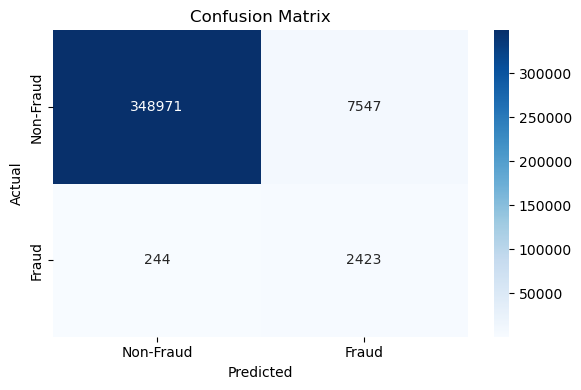

Recall/True Positive Rate: The model got 90.85% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 24.3% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 2.12% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [35]:
y_prob = base_rf_ros.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

# Calibrated CV

In [35]:
from sklearn.calibration import CalibratedClassifierCV

In [36]:
rf = pipeline.get_model()

Returning trained model...


In [58]:
calibrated_rf = CalibratedClassifierCV(
    estimator=rf,
    method='sigmoid',
    cv='prefit'
)

In [59]:
calibrated_rf.fit(X_train_ros, y_train_ros)

CalibratedClassifierCV(cv='prefit',
                       estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                        max_depth=15,
                                                        min_samples_leaf=20,
                                                        n_estimators=1000,
                                                        n_jobs=-1,
                                                        random_state=42))

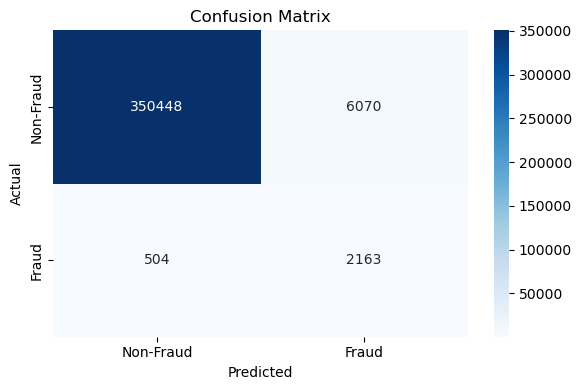

Recall/True Positive Rate: The model got 81.1% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 26.27% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.7% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [60]:
y_prob_cal = calibrated_rf.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob_cal, 0.5)

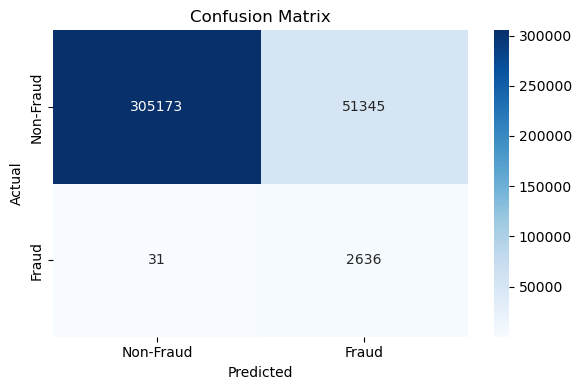

Recall/True Positive Rate: The model got 98.84% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.88% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 14.4% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [67]:
plot_confusion_matrix(y_test, y_prob_cal, 0.001)

# Back-Testing with OOS Data

In [36]:
df_credit_mix = pd.read_parquet("data/base/df_credit_clean_dec24_may25.parquet")
trx_id_list = list(df_credit_mix[df_credit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [37]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['CustomerSex', 'MCC Category', 'POSMode', 'CardProductGrouped',
       'CurrencyCodeGroup'],
      dtype='object')...
Identified numerical columns for imputation: ['Avg_Amt_L15M', 'Avg_Amt_L30D', 'Avg_Amt_to_MCC_L15M', 'Avg_Amt_to_MCC_L30D', 'Avg_Amt_to_countryCode_L15M', 'Avg_Amt_to_countryCode_L30D', 'CntUnique_CardNo_by_MCC_L15M', 'CntUnique_CardNo_by_MCC_L30D', 'CntUnique_CardNo_by_currencyCode_L15M', 'CntUnique_CardNo_by_currencyCode_L30D', 'CntUnique_MCC_by_CardNo_L15M', 'CntUnique_MCC_by_CardNo_L30D', 'Max_Amt_L15M', 'Max_Amt_L30D', 'Max_Amt_to_MCC_L15M', 'Max_Amt_to_MCC_L30D', 'Max_Amt_to_countryCode_L15M', 'Max_Amt_to_countryCode_L30D', 'Sum_Amt_L30D', 'Sum_Amt_to_MCC_L15M', 'Sum_Amt_to_MCC_L30D', 'Sum_Amt_to_count

In [38]:
# Evaluate ALL trx (base RF ROS)
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9853
AUC: 0.9850
PR AUC: 0.5627
Precision: 0.2991
Recall: 0.7332

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.99      0.99    200054
        True       0.30      0.73      0.42      1492

    accuracy                           0.99    201546
   macro avg       0.65      0.86      0.71    201546
weighted avg       0.99      0.99      0.99    201546



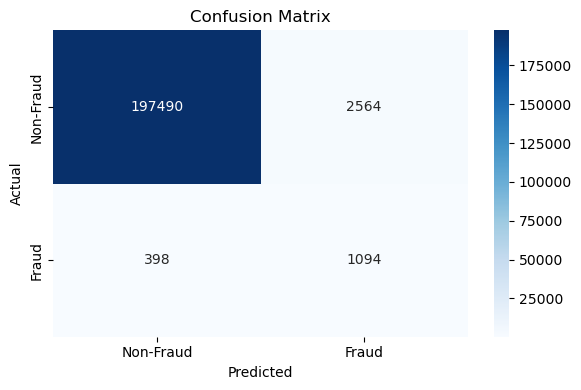

Recall/True Positive Rate: The model got 73.32% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 29.91% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.28% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [41]:
y_oos_prob = base_rf_ros.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

In [38]:
# Evaluate ALL trx (base RF SMOTE)
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9822
AUC: 0.9826
PR AUC: 0.5745
Precision: 0.2606
Recall: 0.7674

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    200054
        True       0.26      0.77      0.39      1492

    accuracy                           0.98    201546
   macro avg       0.63      0.88      0.69    201546
weighted avg       0.99      0.98      0.99    201546



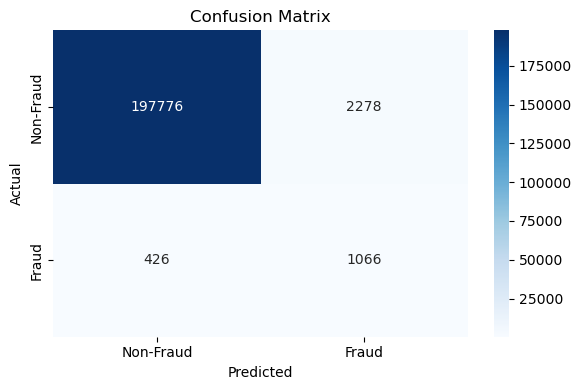

Recall/True Positive Rate: The model got 71.45% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 31.88% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.14% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [54]:
y_oos_prob = base_rf_smote.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

### calibration

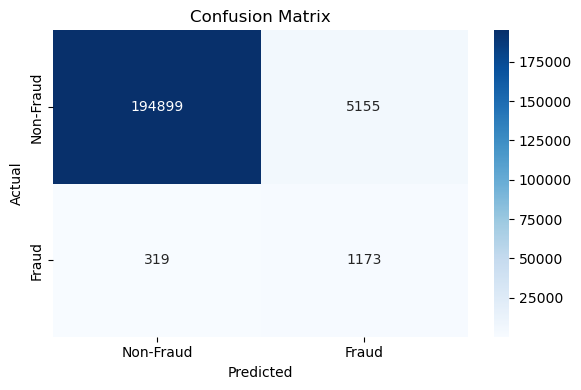

Recall/True Positive Rate: The model got 78.62% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 18.54% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 2.58% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [157]:
y_oos_prob_cal = calibrated_rf.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob_cal, 0.1)

## Threshold Tuning

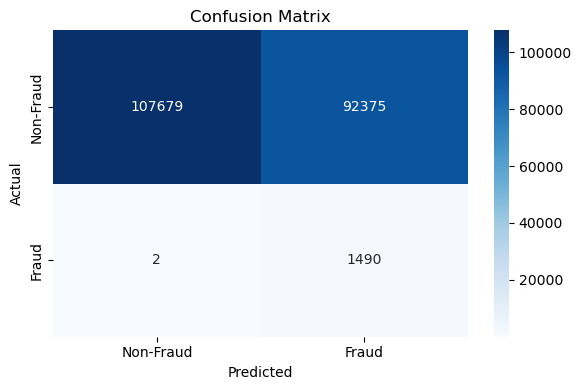

Recall/True Positive Rate: The model got 99.87% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 1.59% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 46.18% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [54]:
plot_confusion_matrix(y_true=y_oos, y_prob=y_oos_prob, threshold=0.015)

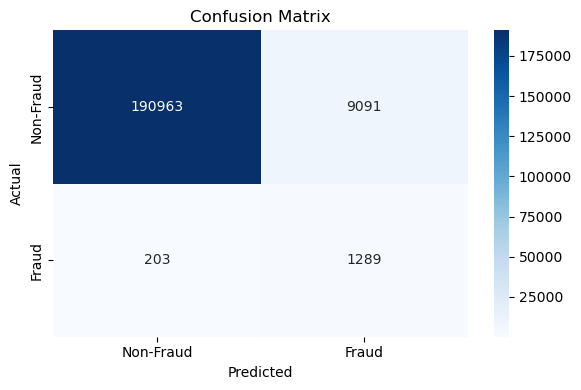

Recall/True Positive Rate: The model got 86.39% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 12.42% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 4.54% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [158]:
plot_confusion_matrix(y_oos, y_oos_prob_cal, 0.015)

# Eval ALERT Transactions Only

In [ ]:
# Evaluate ALERT trx only
X_oos_new, y_oos_new = pipeline.prepare_data(
    # df=df_splits["df_test"],
    df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

In [ ]:
# Evaluate ALERT trx only
oos_results = pipeline.evaluate(X_oos_new, y_oos_new)

In [ ]:
y_oos_new_prob = pipeline.pipeline.predict_proba(X_oos_new)[:, 1]
plot_confusion_matrix(y_oos_new, y_oos_new_prob, 0.5)

# Feature Importance

In [42]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [43]:
pd.set_option("display.max_rows", None)
importance_df['importance'] = np.round(importance_df['importance'], 6)
importance_df

,feature,importance
32,AvgDurationSinceFirstTrnxToCurrentMCCL30D,0.070691
35,TxnCountToPOSModeL15min,0.054794
69,RatioTxnCountToPOSModeL30DL15min,0.050613
9,CntUnique_CardNo_by_currencyCode_L30D,0.050220
79,MCC Category_BUSINESS/PROFESSIONAL/MISCELLANEO...,0.047069
94,POSMode_1,0.035946
64,RatioTxnCountL30DL15min,0.034638
60,RatioCntUnique_CardNo_by_currencyCodeL30DL15min,0.031409
49,Transaction Amount,0.030060
10,CntUnique_MCC_by_CardNo_L15M,0.029960


In [44]:
importance_numeric_cols_df = importance_df[importance_df['feature'].isin(numerical_cols)]

In [45]:
importance_numeric_cols_df.to_csv("data/result/importance/base_rf_118_feats_importance_20250627.csv", index=False)

In [54]:
importance_numeric_cols_df.reset_index(drop=True)

,feature,importance
0,AvgDurationSinceFirstTrnxToCurrentMCCL30D,0.070691
1,TxnCountToPOSModeL15min,0.054794
2,RatioTxnCountToPOSModeL30DL15min,0.050613
3,CntUnique_CardNo_by_currencyCode_L30D,0.050220
4,RatioTxnCountL30DL15min,0.034638
5,RatioCntUnique_CardNo_by_currencyCodeL30DL15min,0.031409
6,Transaction Amount,0.030060
7,CntUnique_MCC_by_CardNo_L15M,0.029960
8,time_diff,0.029752
9,RatioCntUnique_MCC_by_CardNoL30DL15min,0.026702


In [48]:
importance_numeric_cols_df.head(25).feature.tolist()

['AvgDurationSinceFirstTrnxToCurrentMCCL30D',
 'TxnCountToPOSModeL15min',
 'RatioTxnCountToPOSModeL30DL15min',
 'CntUnique_CardNo_by_currencyCode_L30D',
 'RatioTxnCountL30DL15min',
 'RatioCntUnique_CardNo_by_currencyCodeL30DL15min',
 'Transaction Amount',
 'CntUnique_MCC_by_CardNo_L15M',
 'time_diff',
 'RatioCntUnique_MCC_by_CardNoL30DL15min',
 'TxnCount_L15M',
 'RatioTxnCount_to_countryCodeL30DL15min',
 'RatioTxnCount_to_MCCL30DL15min',
 'RatioSum_Amt_to_MCCL30DL15min',
 'TxnCount_to_countryCode_L15M',
 'Max_Amt_to_MCC_L30D',
 'RatioAvgDurationSinceFirstTrnxToCurrentMCCL30DL15min',
 'RatioSum_Amt_to_countryCodeL30DL15min',
 'AvgDurationSinceFirstTrnxToCurrentMCCL15min',
 'Sum_Amt_to_MCC_L30D',
 'IsTop10HighRiskMCCLast30D',
 'TotalTrxAmount10Mi',
 'AvgDurationSinceFirstTrnxToCurrentCountryCodeL30D',
 'TotalTrxAmount15Mi',
 'CntUnique_CardNo_by_MCC_L30D']

In [52]:
importance_numeric_cols_df

,feature,importance
32,AvgDurationSinceFirstTrnxToCurrentMCCL30D,0.070691
35,TxnCountToPOSModeL15min,0.054794
69,RatioTxnCountToPOSModeL30DL15min,0.050613
9,CntUnique_CardNo_by_currencyCode_L30D,0.050220
64,RatioTxnCountL30DL15min,0.034638
60,RatioCntUnique_CardNo_by_currencyCodeL30DL15min,0.031409
49,Transaction Amount,0.030060
10,CntUnique_MCC_by_CardNo_L15M,0.029960
43,time_diff,0.029752
53,RatioCntUnique_MCC_by_CardNoL30DL15min,0.026702


# Train High-Precision Model

In [143]:
threshold = 0.5
mask = y_prob_cal < threshold

In [144]:
mask_series = pd.Series(mask, index=X_test.index)
X_candidates = X_test.loc[mask_series]
y_candidates = y_test.loc[mask_series]

In [145]:
X_test.shape, X_candidates.shape

((359185, 72), (350952, 72))

In [146]:
# split data
X_cdd_train, X_cdd_test, y_cdd_train, y_cdd_test = pipeline.split_data(
    X_candidates, y_candidates, test_size=0.2
)

Splitting data into train and test sets...
Data splitting complete.


In [147]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_cdd_train_ros, y_cdd_train_ros = ros_sampler.fit_resample(X_cdd_train, y_cdd_train)

Original dataset shape: Counter({False: 280358, True: 403})
Resampled dataset shape using RandomOverSampler: Counter({False: 280358, True: 56071})


In [148]:
# re-init
pipeline = ModelPipeline(
    model_type="xgboost",
    random_state=42
)
# built and train
pipeline.build_pipeline()
pipeline.train(X_cdd_train_ros, y_cdd_train_ros, show_training_log=False)

Initializing ModelPipeline with model type: xgboost
Retrieving model instance for type: xgboost
Building pipeline...
Pipeline built.
Training model...


C:\Users\Administrator\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:17:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.


In [149]:
xgb = pipeline.get_model()

Returning trained model...


In [150]:
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb,
    method='sigmoid',
    cv='prefit'
)
calibrated_xgb.fit(X_cdd_train_ros, y_cdd_train_ros)

CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=1000, n_jobs=-1,
                                               num_parallel_tree=None, ...))

In [151]:
# Evaluate
cdd_test_results = pipeline.evaluate(X_cdd_test, y_cdd_test)

Evaluating model...
Accuracy: 0.9980
AUC: 0.8419
PR AUC: 0.0868
Precision: 0.2029
Recall: 0.1386

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     70090
        True       0.20      0.14      0.16       101

    accuracy                           1.00     70191
   macro avg       0.60      0.57      0.58     70191
weighted avg       1.00      1.00      1.00     70191



## Backtest with OOS Data

In [152]:
threshold_oos = 0.5
mask_oos = y_oos_prob_cal < threshold_oos

In [153]:
mask_oos_series = pd.Series(mask_oos, index=X_oos.index)
X_oos_cdd = X_oos.loc[mask_oos_series]
y_oos_cdd = y_oos.loc[mask_oos_series]

In [154]:
y_oos_cdd_prob = xgb.predict_proba(X_oos_cdd)[:, 1]

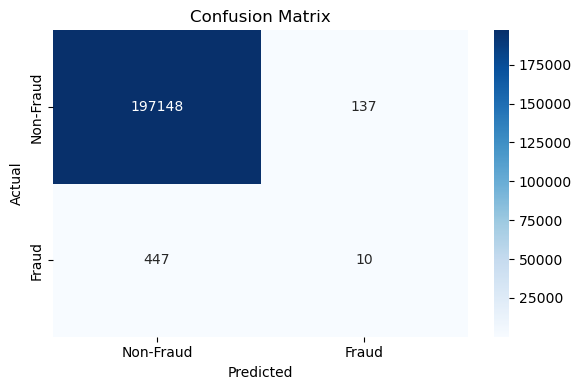

Recall/True Positive Rate: The model got 2.19% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 6.8% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.07% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [155]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_prob, 0.5)

In [103]:
y_oos_cdd_prob_cal = calibrated_xgb.predict_proba(X_oos_cdd)[:, 1]

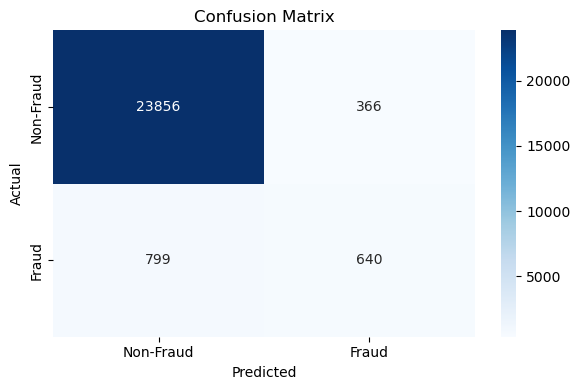

Recall/True Positive Rate: The model got 44.48% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 63.62% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.51% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [109]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_prob_cal, 0.5)

In [110]:
y_oos_cdd_rf_cal = calibrated_rf.predict_proba(X_oos_cdd)[:, 1]

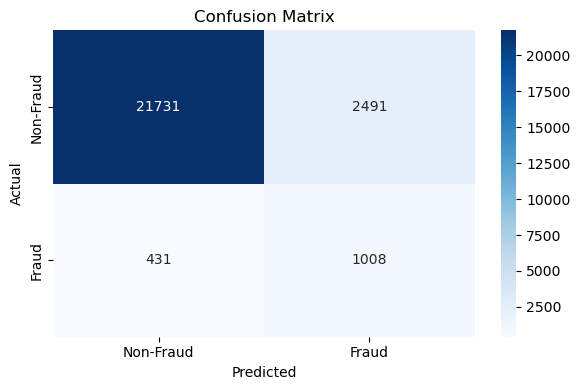

Recall/True Positive Rate: The model got 70.05% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 28.81% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 10.28% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [133]:
plot_confusion_matrix(y_oos_cdd, y_oos_cdd_rf_cal, 0.6)

## Combine Proba

In [114]:
y_oos_rf = calibrated_rf.predict_proba(X_oos)[:, 1]
y_oos_xgb = calibrated_xgb.predict_proba(X_oos)[:, 1]

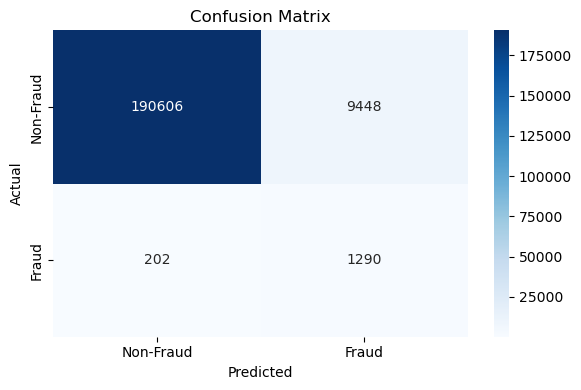

Recall/True Positive Rate: The model got 86.46% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 12.01% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 4.72% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [126]:
rf_prop = 0.1
xgb_prop = 0.9

y_oos_combine = (y_oos_rf * rf_prop) + (y_oos_xgb * xgb_prop)
plot_confusion_matrix(y_oos, y_oos_combine, 0.0015)

## Analysis

In [130]:
df_analysis_post_rf_base = X_oos_cdd.copy()
df_analysis_post_rf_base["Confirmed"] = y_oos_cdd
df_analysis_post_rf_base["RF_cal_proba"] = calibrated_rf.predict_proba(X_oos_cdd)[:, 1]
df_analysis_post_rf_base = df_analysis_post_rf_base[["Confirmed","RF_cal_proba"]]

<Axes: xlabel='RF_cal_proba', ylabel='Density'>

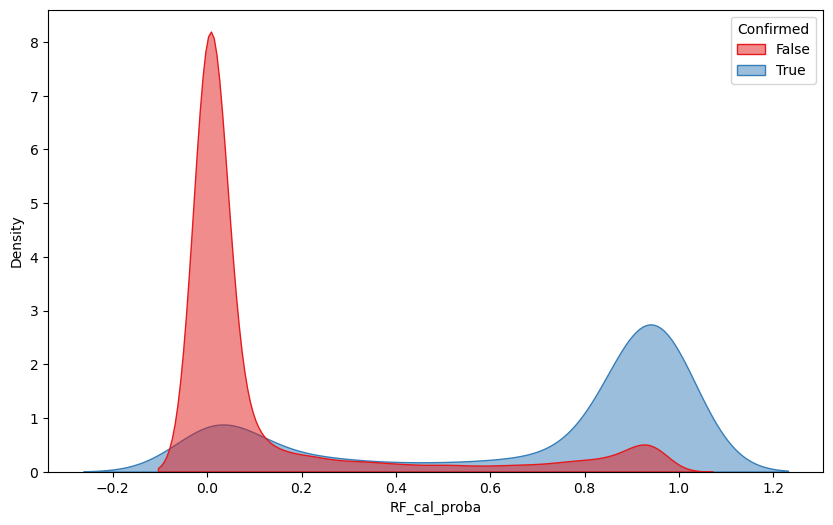

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df_analysis_post_rf_base,
    x="RF_cal_proba",
    hue="Confirmed",
    common_norm=False,
    fill=True,
    palette="Set1",
    alpha=0.5
)